In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
from sklearn.datasets import make_blobs

X,y=make_blobs(n_samples=1000,n_features=2,centers=3, random_state=7)
X

array([[ 9.82963246,  0.76309415],
       [-9.72354778,  4.10078753],
       [10.40345668,  1.76167097],
       ...,
       [-0.76776985,  3.67076765],
       [-0.88599094,  4.23629989],
       [-8.79724584,  5.75272083]])

In [63]:
y

array([2, 0, 2, 1, 2, 2, 0, 2, 0, 1, 1, 1, 2, 1, 0, 2, 1, 2, 1, 0, 1, 2,
       0, 0, 1, 0, 2, 1, 0, 0, 2, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 0,
       1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 0, 2, 2, 1, 0, 1, 1, 2,
       1, 2, 0, 2, 2, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 2, 0, 0, 1, 1, 1,
       0, 2, 1, 0, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2,
       2, 1, 0, 2, 1, 1, 0, 0, 0, 2, 0, 0, 2, 1, 2, 0, 0, 2, 1, 0, 1, 2,
       1, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 2, 2, 0, 0, 2, 0, 0, 2, 1, 0, 1,
       1, 0, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 2, 0, 1, 0, 2, 2, 1, 1,
       0, 2, 1, 2, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 2, 0, 0, 2, 2, 1, 2, 2,
       0, 2, 0, 2, 0, 1, 0, 1, 1, 2, 2, 2, 1, 0, 1, 1, 2, 2, 0, 2, 2, 2,
       2, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0, 0, 1, 2, 0, 1, 0,
       2, 2, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 1, 2, 0, 0, 0, 2,
       0, 1, 1, 0, 2, 2, 1, 0, 1, 0, 2, 1, 0, 2, 1,

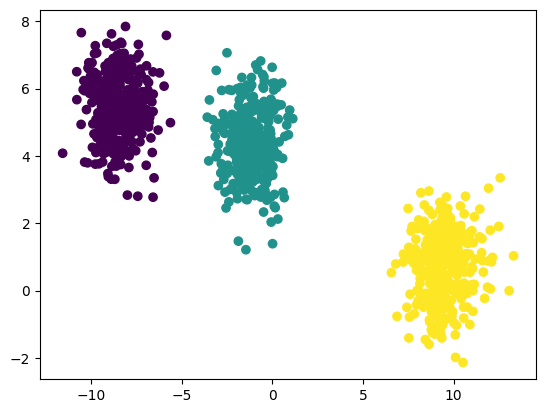

In [64]:

plt.scatter(X[:,0],X[:,1],c=y)

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33, random_state=7)


In [66]:
X_train.shape

(670, 2)

In [67]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

[1339.9999999999993, 263.3483889293885, 136.4299280632516, 106.80086029830181, 81.00209956807443, 73.86505949831218, 48.07558872846601, 40.543944144767494, 33.851638263416994, 36.001086555131714]


Text(0, 0.5, 'Inertia Values')

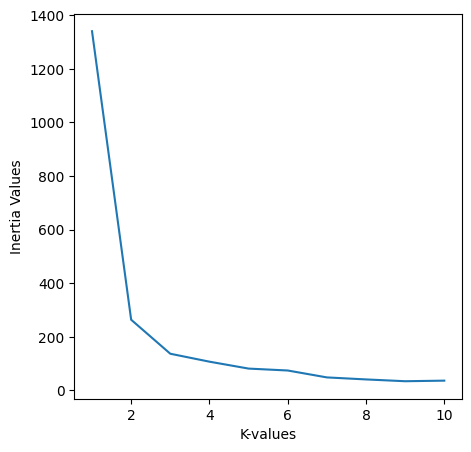

In [68]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmean=KMeans(n_clusters=i,init="k-means++")
  kmean.fit(X_train)
  wcss.append(kmean.inertia_)
print(wcss)
plt.figure(figsize=(5,5))
plt.plot(range(1,11), wcss)
plt.xlabel("K-values")
plt.ylabel("Inertia Values")

In [69]:
!pip install kneed

In [70]:
from kneed import KneeLocator
k1=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")


In [71]:
k1.elbow

2

In [72]:
kmean=KMeans(n_clusters=2,init="k-means++")
kmean.fit(X_train)
y_pred=kmean.predict(X_test)

In [73]:
y_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,

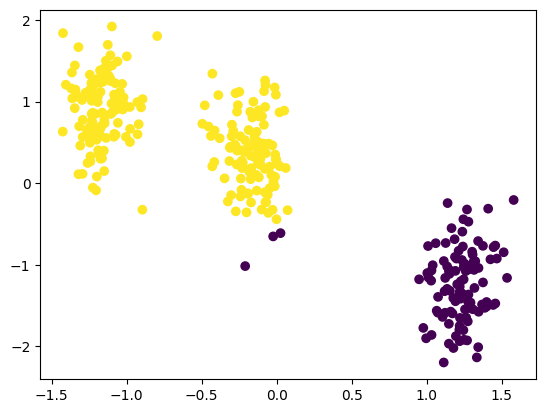

In [74]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [75]:
## silhouette score

from sklearn.metrics import silhouette_score

silhouette_coeff=[]
for i in range(2,11):
  kmean=KMeans(n_clusters=i,init="k-means++")
  kmean.fit(X_train)
  score=silhouette_score(X_train,kmean.labels_)
  silhouette_coeff.append(score)

silhouette_coeff

[0.7071211454767184,
 0.618815010159288,
 0.5763966512755355,
 0.5695353062868855,
 0.48505923781206695,
 0.4706549119051289,
 0.4394228365830378,
 0.4275400812101411,
 0.3994660444014084]

Text(0, 0.5, 'Silhouette Score')

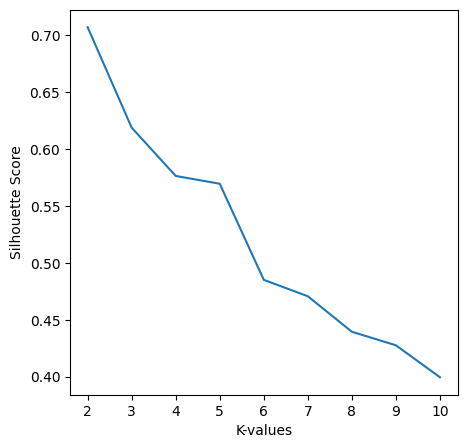

In [76]:
plt.figure(figsize=(5,5))
plt.plot(range(2,11), silhouette_coeff)
plt.xlabel("K-values")
plt.ylabel("Silhouette Score")